In [3]:
import os
import numpy as np
import tifffile
import pandas as pd
from scipy import ndimage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =========================================================
# IMPORTANT CAVEAT -- READ BEFORE USING THESE RESULTS
# -----------------------------------------------------------------
# This file is a single-channel time-lapse (T=67 timepoints), with
# NO separate structural/nuclear marker channel. That means cell
# segmentation here has to be done directly on the jGCaMP8m signal
# itself -- there is no independent channel to reveal cells that
# express little or no jGCaMP8m.
#
# Consequence: any cell with truly negligible jGCaMP8m expression
# may simply be invisible in this recording and never get segmented
# at all. The "transduction efficiency" computed below is therefore
# best understood as "the percentage of DETECTABLE cells whose mean
# jGCaMP8m signal exceeds an intensity threshold" -- NOT a true
# efficiency relative to the total number of cells physically
# present in the tissue (which would require an independent
# structural channel, e.g. a nuclear stain, to establish that
# denominator).
#
# If you have a separate multi-channel snapshot image of the same
# sample (structural marker + jGCaMP8m) from a fixed/non-time-lapse
# acquisition, that image is the correct one to use for a proper
# transduction efficiency measurement. Use this script only if no
# such image exists, and report the caveat above alongside any
# efficiency number derived from it.
# =========================================================

# =========================================================
# 0. INPUT
# =========================================================
image_path = "20260310_E14TG2a_r26A_DIV22_PU1_MF_SirActin674_jGcamp488_20x_TimeLaps50ms-03.tif"   # <-- your time-lapse file
condition_label = "VLP400 jGCaMP8m"
cell_line = "E14Tg2a"                # <-- edit

projection_method = "mean"           # "mean" (baseline expression, recommended) or "max" (peak activity)

model_type = "cyto3"
diameter = None
use_gpu = True

output_dir = os.path.dirname(os.path.abspath(image_path)) or "."
base_name = os.path.splitext(os.path.basename(image_path))[0]

# =========================================================
# 1. Load time-lapse and compute a temporal projection
# =========================================================
movie = tifffile.imread(image_path)
print("Movie shape (T, Y, X):", movie.shape)

if movie.ndim != 3:
    raise ValueError(f"Expected a 3D (T, Y, X) time-lapse, got shape {movie.shape}")

if projection_method == "mean":
    projection = movie.mean(axis=0)
elif projection_method == "max":
    projection = movie.max(axis=0)
else:
    raise ValueError("projection_method must be 'mean' or 'max'")

projection = projection.astype(np.float32)
print(f"Computed {projection_method} projection, shape:", projection.shape)

# =========================================================
# 2. Segment cells on the projection (2D, single image)
# =========================================================
from cellpose import models

if hasattr(models, "Cellpose"):
    model = models.Cellpose(gpu=use_gpu, model_type=model_type)
    api_version = "legacy"
else:
    model = models.CellposeModel(gpu=use_gpu, model_type=model_type)
    api_version = "new"
print(f"Using Cellpose API: {api_version}")

# normalize projection to 0-255 range for more consistent Cellpose behavior
proj_norm = (projection - projection.min()) / (projection.max() - projection.min() + 1e-9)
proj_uint8 = (proj_norm * 255).astype(np.uint8)

if api_version == "legacy":
    masks, flows, styles, diams = model.eval(proj_uint8, diameter=diameter, channels=[0, 0])
else:
    masks, flows, styles = model.eval(proj_uint8, diameter=diameter, channels=[0, 0])

n_cells_detected = masks.max()
print(f"Cells detected on {projection_method} projection: {n_cells_detected}")

if n_cells_detected == 0:
    raise ValueError(
        "0 cells detected on the projection. Try the other projection_method, "
        "check the 'diameter' setting, or inspect proj_uint8 visually to confirm "
        "cells are actually visible in this projection."
    )

seg_npy_path = os.path.join(output_dir, f"{base_name}_seg.npy")
np.save(seg_npy_path, masks)
print(f"Saved segmentation masks to: {seg_npy_path}")

# =========================================================
# 3. Per-cell measurements (on the projection)
# =========================================================
labels = np.unique(masks)
labels = labels[labels != 0]

mean_intensities = ndimage.mean(projection, labels=masks, index=labels)
areas = ndimage.sum(np.ones_like(masks), labels=masks, index=labels)

df = pd.DataFrame({"label": labels, "area": areas, "mean_intensity": mean_intensities})
print(f"Total segmented cells: {len(df)}")

# =========================================================
# 4. Background subtraction
# =========================================================
bg = np.median(projection[masks == 0])
df["corrected_intensity"] = df["mean_intensity"] - bg
print(f"Background level: {bg:.1f}")

# =========================================================
# 5. Otsu threshold (no skimage dependency)
# =========================================================
def otsu_threshold(values, bins=256):
    hist, bin_edges = np.histogram(values, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    weight1 = np.cumsum(hist)
    weight2 = np.cumsum(hist[::-1])[::-1]
    mean1 = np.cumsum(hist * bin_centers) / np.maximum(weight1, 1)
    mean2 = (np.cumsum((hist * bin_centers)[::-1]) / np.maximum(weight2[::-1], 1))[::-1]
    variance12 = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:]) ** 2
    idx = np.argmax(variance12)
    return bin_centers[idx]

threshold = otsu_threshold(df["corrected_intensity"].values)
df["positive"] = df["corrected_intensity"] > threshold

# =========================================================
# 6. Efficiency (see CAVEAT at top of script)
# =========================================================
total_cells = len(df)
positive_cells = int(df["positive"].sum())
efficiency = 100 * positive_cells / total_cells

print(f"Threshold used: {threshold:.1f}")
print(f"jGCaMP8m-positive cells: {positive_cells}")
print(f"Apparent transduction efficiency (of DETECTABLE cells): {efficiency:.2f}%")
print("REMINDER: this does not account for cells invisible in this single-channel "
      "recording -- see caveat at the top of this script.")

# =========================================================
# 7. Save per-cell results
# =========================================================
csv_path = os.path.join(output_dir, f"{base_name}_{cell_line}_jGCaMP8m_transduction_results.csv")
df.to_csv(csv_path, index=False)
print(f"Saved per-cell results to: {csv_path}")

# =========================================================
# 8. Summary figure
# =========================================================
FG_COLOR = "#000000"
ACCENT_COLOR = "#3AA65C"
THRESH_COLOR = "#D9534F"
GRID_EDGE = "#DDDDDD"

svg_path = os.path.join(output_dir, f"{base_name}_{cell_line}_jGCaMP8m_transduction_summary.svg")
png_path = os.path.join(output_dir, f"{base_name}_{cell_line}_jGCaMP8m_transduction_summary.png")

fig = plt.figure(figsize=(10, 4), facecolor="white")
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1])

ax0 = fig.add_subplot(gs[0])
ax0.set_facecolor("white")
ax0.hist(df["corrected_intensity"], bins=50, color=ACCENT_COLOR, edgecolor="none")
ax0.axvline(threshold, color=THRESH_COLOR, linestyle="--", linewidth=1.5,
            label=f"Threshold = {threshold:.1f}")
ax0.set_xlabel(f"Background-corrected {projection_method} intensity per cell", color=FG_COLOR)
ax0.set_ylabel("Cell count", color=FG_COLOR)
ax0.set_title(f"{condition_label} apparent transduction efficiency ({cell_line})\n"
              f"[from {projection_method} projection of time-lapse -- see caveat]",
              color=FG_COLOR, fontsize=11)
ax0.tick_params(colors=FG_COLOR)
for spine in ax0.spines.values():
    spine.set_color(FG_COLOR)
ax0.spines[['top', 'right']].set_visible(False)
ax0.legend(frameon=False, labelcolor=FG_COLOR)

ax1 = fig.add_subplot(gs[1])
ax1.axis("off")
ax1.set_facecolor("white")
summary_data = [
    ["Cell line", f"{cell_line}"],
    ["Reporter", "jGCaMP8m (VLP)"],
    ["Projection", f"{projection_method} (T={movie.shape[0]})"],
    ["Total cells", f"{total_cells}"],
    ["Positive cells", f"{positive_cells}"],
    ["Threshold", f"{threshold:.1f}"],
    ["Background", f"{bg:.1f}"],
    ["Apparent\nefficiency", f"{efficiency:.1f}%"],
]
table = ax1.table(cellText=summary_data, cellLoc="left", loc="center", colWidths=[0.55, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 1.9)
for key, cell in table.get_celld().items():
    cell.set_edgecolor(GRID_EDGE)
    if key[0] == len(summary_data) - 1:
        cell.set_text_props(weight="bold")

plt.tight_layout()
plt.savefig(svg_path, format="svg", facecolor="white", edgecolor="none", bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=300, facecolor="white", edgecolor="none", bbox_inches="tight")
print(f"Saved figure to: {svg_path}")
print(f"Saved figure to: {png_path}")

plt.show()

Movie shape (T, Y, X): (2, 7113, 2, 1784, 1776)


ValueError: Expected a 3D (T, Y, X) time-lapse, got shape (2, 7113, 2, 1784, 1776)

Full array shape: (2, 4, 17, 2192, 2192) | dtype: uint8
Full array would be ~0.7 GB in RAM -- using memmap + chunking instead.
Scenes: 2 | Frames: 4 | Channels: 17 | Frame: 2192x2192

Channel intensity check (first frame, scene 0) -- use this to confirm channel assignment:
  channel 0: min=0, max=18, mean=0.0, median=0.0
  channel 1: min=0, max=111, mean=0.0, median=0.0
  channel 2: min=0, max=25, mean=0.0, median=0.0
  channel 3: min=0, max=29, mean=0.0, median=0.0
  channel 4: min=0, max=22, mean=0.0, median=0.0
  channel 5: min=0, max=25, mean=0.0, median=0.0
  channel 6: min=0, max=30, mean=0.0, median=0.0
  channel 7: min=0, max=22, mean=0.0, median=0.0
  channel 8: min=0, max=20, mean=0.0, median=0.0
  channel 9: min=0, max=26, mean=0.0, median=0.0
  channel 10: min=0, max=24, mean=0.0, median=0.0
  channel 11: min=0, max=21, mean=0.0, median=0.0
  channel 12: min=0, max=23, mean=0.0, median=0.0
  channel 13: min=0, max=26, mean=0.0, median=0.0
  channel 14: min=0, max=22, mean=0

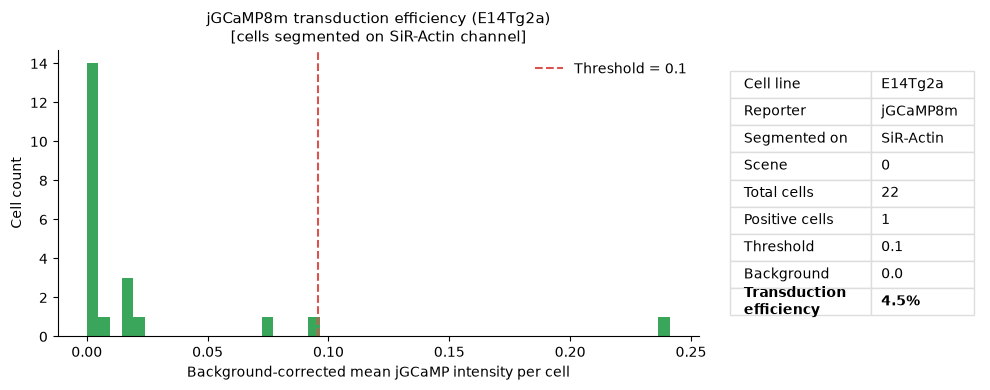

In [5]:
import os
import numpy as np
import tifffile
import pandas as pd
from scipy import ndimage
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =========================================================
# 0. INPUT
# -----------------------------------------------------------------
# Shape here is (S, T, C, Y, X) = (2, 7113, 2, 1784, 1776):
#   S = 2 scenes/positions
#   T = 7113 timepoints
#   C = 2 channels (SiR-Actin 674 + jGCaMP 488)
#   Y, X = 1784 x 1776 pixels
#
# NOTE: this file is ~180 GB if fully loaded. All operations below
# are memory-mapped and chunked -- never call .mean() or similar on
# the whole array.
# =========================================================
image_path = "20260310_E14TG2a_r26A_DIV22_PU1_MF_SirActin674_jGcamp488_20x_zStack-01.tif"

scene_index = 0                  # which scene/position to analyse
structural_channel = 0           # <-- SiR-Actin channel index (VERIFY: see step 1 output)
gcamp_channel = 1                # <-- jGCaMP channel index (VERIFY: see step 1 output)

condition_label = "jGCaMP8m"
cell_line = "E14Tg2a"

n_projection_frames = 200        # how many timepoints to average for the projection
                                  # (200 of 7113 is plenty and avoids reading 180 GB)
chunk_size = 20                  # frames read at a time

model_type = "cyto3"
diameter = None
use_gpu = True

output_dir = os.path.dirname(os.path.abspath(image_path)) or "."
base_name = os.path.splitext(os.path.basename(image_path))[0]

# =========================================================
# 1. Open memory-mapped (does NOT load into RAM)
# =========================================================
movie = tifffile.memmap(image_path, mode="r")
print("Full array shape:", movie.shape, "| dtype:", movie.dtype)
est_gb = np.prod(movie.shape) * movie.dtype.itemsize / 1e9
print(f"Full array would be ~{est_gb:.1f} GB in RAM -- using memmap + chunking instead.")

if movie.ndim != 5:
    raise ValueError(f"This script expects a 5D (S, T, C, Y, X) array, got {movie.shape}")

n_scenes, n_frames, n_channels, ny, nx = movie.shape
print(f"Scenes: {n_scenes} | Frames: {n_frames} | Channels: {n_channels} | Frame: {ny}x{nx}")

# --- sanity check the two channels so you can confirm which is which ---
print("\nChannel intensity check (first frame, scene "
      f"{scene_index}) -- use this to confirm channel assignment:")
for c in range(n_channels):
    plane = np.asarray(movie[scene_index, 0, c])
    print(f"  channel {c}: min={plane.min()}, max={plane.max()}, "
          f"mean={plane.mean():.1f}, median={np.median(plane):.1f}")
print(f"-> currently using channel {structural_channel} for SEGMENTATION (SiR-Actin)")
print(f"-> currently using channel {gcamp_channel} for jGCaMP quantification\n")

# =========================================================
# 2. Chunked mean projection of the STRUCTURAL channel
# -----------------------------------------------------------------
# Averaged over a subset of timepoints spread across the recording,
# read in small chunks so memory stays low.
# =========================================================
frame_idx = np.linspace(0, n_frames - 1, n_projection_frames).astype(int)

accum = np.zeros((ny, nx), dtype=np.float64)
for start in range(0, len(frame_idx), chunk_size):
    idx = frame_idx[start:start + chunk_size]
    block = np.asarray(movie[scene_index, idx, structural_channel]).astype(np.float64)
    accum += block.sum(axis=0)
    print(f"  projection: {min(start + chunk_size, len(frame_idx))}/{len(frame_idx)} frames", end="\r")

structural_projection = accum / len(frame_idx)
print(f"\nStructural projection computed, shape: {structural_projection.shape}")

# =========================================================
# 3. Segment cells on the STRUCTURAL channel projection
# -----------------------------------------------------------------
# This is the key improvement over segmenting on jGCaMP itself:
# SiR-Actin labels cells regardless of whether they express the
# reporter, so the denominator of the efficiency calculation
# includes non-transduced cells.
# =========================================================
from cellpose import models

if hasattr(models, "Cellpose"):
    model = models.Cellpose(gpu=use_gpu, model_type=model_type)
    api_version = "legacy"
else:
    model = models.CellposeModel(gpu=use_gpu, model_type=model_type)
    api_version = "new"
print(f"Using Cellpose API: {api_version}")

proj_norm = (structural_projection - structural_projection.min()) / \
            (structural_projection.max() - structural_projection.min() + 1e-9)
proj_uint8 = (proj_norm * 255).astype(np.uint8)

if api_version == "legacy":
    masks, flows, styles, diams = model.eval(proj_uint8, diameter=diameter, channels=[0, 0])
else:
    masks, flows, styles = model.eval(proj_uint8, diameter=diameter, channels=[0, 0])

n_detected = int(masks.max())
print(f"Cells detected on structural channel: {n_detected}")

if n_detected == 0:
    raise ValueError(
        "0 cells detected. Check that structural_channel points to the SiR-Actin "
        "channel (see the intensity check in step 1), and try setting an explicit "
        "'diameter' value."
    )

seg_npy_path = os.path.join(output_dir, f"{base_name}_scene{scene_index}_seg.npy")
np.save(seg_npy_path, masks)
print(f"Saved masks to: {seg_npy_path}")

# =========================================================
# 4. Chunked mean projection of the jGCaMP channel
# =========================================================
accum = np.zeros((ny, nx), dtype=np.float64)
for start in range(0, len(frame_idx), chunk_size):
    idx = frame_idx[start:start + chunk_size]
    block = np.asarray(movie[scene_index, idx, gcamp_channel]).astype(np.float64)
    accum += block.sum(axis=0)
    print(f"  gcamp projection: {min(start + chunk_size, len(frame_idx))}/{len(frame_idx)}", end="\r")

gcamp_projection = accum / len(frame_idx)
print(f"\njGCaMP projection computed, shape: {gcamp_projection.shape}")

# =========================================================
# 5. Per-cell measurements on the jGCaMP channel
# =========================================================
labels = np.unique(masks)
labels = labels[labels != 0]

mean_intensities = ndimage.mean(gcamp_projection, labels=masks, index=labels)
areas = ndimage.sum(np.ones_like(masks), labels=masks, index=labels)

df = pd.DataFrame({"label": labels, "area": areas, "mean_intensity": mean_intensities})
print(f"Total segmented cells: {len(df)}")

bg = np.median(gcamp_projection[masks == 0])
df["corrected_intensity"] = df["mean_intensity"] - bg
print(f"Background level: {bg:.1f}")

# =========================================================
# 6. Otsu threshold + efficiency
# =========================================================
def otsu_threshold(values, bins=256):
    hist, bin_edges = np.histogram(values, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    weight1 = np.cumsum(hist)
    weight2 = np.cumsum(hist[::-1])[::-1]
    mean1 = np.cumsum(hist * bin_centers) / np.maximum(weight1, 1)
    mean2 = (np.cumsum((hist * bin_centers)[::-1]) / np.maximum(weight2[::-1], 1))[::-1]
    variance12 = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:]) ** 2
    return bin_centers[np.argmax(variance12)]


threshold = otsu_threshold(df["corrected_intensity"].values)
df["positive"] = df["corrected_intensity"] > threshold

total_cells = len(df)
positive_cells = int(df["positive"].sum())
efficiency = 100 * positive_cells / total_cells

print(f"\nThreshold: {threshold:.1f}")
print(f"jGCaMP-positive cells: {positive_cells}")
print(f"Transduction efficiency: {efficiency:.2f}%")
print("NOTE: because segmentation used the independent SiR-Actin channel, this is a "
      "TRUE transduction efficiency -- non-expressing cells are included in the "
      "denominator. The single-channel caveat from earlier analyses does not apply here.")

csv_path = os.path.join(output_dir, f"{base_name}_scene{scene_index}_{cell_line}_transduction.csv")
df.to_csv(csv_path, index=False)
print(f"Saved per-cell results to: {csv_path}")

# =========================================================
# 7. Summary figure
# =========================================================
FG, ACCENT, THRESH_C, EDGE = "#000000", "#3AA65C", "#D9534F", "#DDDDDD"

fig = plt.figure(figsize=(10, 4), facecolor="white")
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1])

ax0 = fig.add_subplot(gs[0])
ax0.hist(df["corrected_intensity"], bins=50, color=ACCENT, edgecolor="none")
ax0.axvline(threshold, color=THRESH_C, linestyle="--", linewidth=1.5,
            label=f"Threshold = {threshold:.1f}")
ax0.set_xlabel("Background-corrected mean jGCaMP intensity per cell", color=FG)
ax0.set_ylabel("Cell count", color=FG)
ax0.set_title(f"{condition_label} transduction efficiency ({cell_line})\n"
              f"[cells segmented on SiR-Actin channel]", color=FG, fontsize=11)
ax0.legend(frameon=False)
ax0.spines[['top', 'right']].set_visible(False)

ax1 = fig.add_subplot(gs[1])
ax1.axis("off")
summary_data = [
    ["Cell line", cell_line],
    ["Reporter", condition_label],
    ["Segmented on", "SiR-Actin"],
    ["Scene", f"{scene_index}"],
    ["Total cells", f"{total_cells}"],
    ["Positive cells", f"{positive_cells}"],
    ["Threshold", f"{threshold:.1f}"],
    ["Background", f"{bg:.1f}"],
    ["Transduction\nefficiency", f"{efficiency:.1f}%"],
]
table = ax1.table(cellText=summary_data, cellLoc="left", loc="center", colWidths=[0.55, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.75)
for key, cell in table.get_celld().items():
    cell.set_edgecolor(EDGE)
    if key[0] == len(summary_data) - 1:
        cell.set_text_props(weight="bold")

plt.tight_layout()
svg_path = os.path.join(output_dir, f"{base_name}_scene{scene_index}_{cell_line}_summary.svg")
png_path = os.path.join(output_dir, f"{base_name}_scene{scene_index}_{cell_line}_summary.png")
plt.savefig(svg_path, format="svg", facecolor="white", bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=300, facecolor="white", bbox_inches="tight")
print(f"Saved figure to: {svg_path}")
print(f"Saved figure to: {png_path}")

plt.show()